<a href="https://colab.research.google.com/github/Innovatewithapple/Classification/blob/main/ChurnClassification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
from google.colab import userdata

In [2]:
os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

print("Kaggle API activated via Secrets!")

Kaggle API activated via Secrets!


In [3]:
!kaggle datasets download -d blastchar/telco-customer-churn

Dataset URL: https://www.kaggle.com/datasets/blastchar/telco-customer-churn
License(s): copyright-authors
100% 172k/172k [00:00<00:00, 257kB/s]



In [4]:
!unzip -q /content/telco-customer-churn.zip -d /content/

In [5]:
!ls /content/

sample_data  telco-customer-churn.zip  WA_Fn-UseC_-Telco-Customer-Churn.csv


Start

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,cross_validate,GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

In [7]:
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [8]:
df.sample(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
6729,2256-YLYLP,Male,0,Yes,Yes,68,Yes,No,DSL,No,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),72.95,4953.25,No
1084,9170-ARBTB,Female,0,Yes,Yes,52,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Credit card (automatic),19.60,1012.4,No
5771,1539-LNKHM,Female,0,No,No,12,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.40,266.6,No
2532,9825-YCXWZ,Female,1,No,No,41,Yes,No,Fiber optic,No,...,Yes,Yes,Yes,Yes,One year,Yes,Bank transfer (automatic),101.10,4016.2,No
810,2239-JALAW,Male,0,No,No,58,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Bank transfer (automatic),103.25,6017.65,Yes


In [9]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [10]:
df.shape

(7043, 21)

In [11]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [12]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [13]:
(df['TotalCharges'] == " ").sum()

np.int64(11)

In [14]:
df['TotalCharges'].unique()

array(['29.85', '1889.5', '108.15', ..., '346.45', '306.6', '6844.5'],
      dtype=object)

In [15]:
# fill totalcharges with 0
df['TotalCharges'] = df['TotalCharges'].replace(" ", np.nan)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])
df['TotalCharges'].fillna(0,inplace=True)

/tmp/ipykernel_1416/4202676271.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(0,inplace=True)


In [16]:
df['TotalCharges'].dtypes

dtype('float64')

In [17]:
df = df.drop(columns='customerID')

<Axes: xlabel='Churn', ylabel='count'>

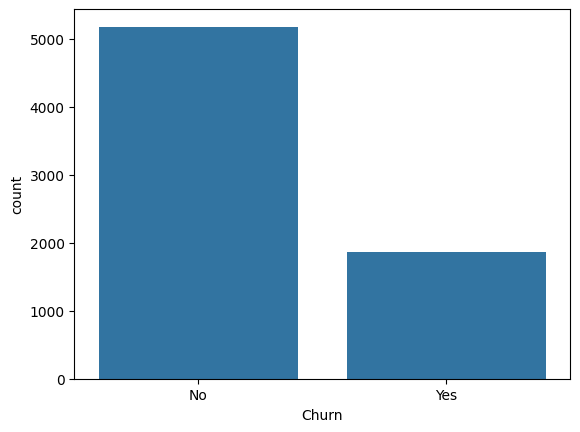

In [18]:
# checking if data is balanced or imbalanced, based on churn
sns.countplot(x='Churn',data=df)

<Axes: xlabel='Contract', ylabel='count'>

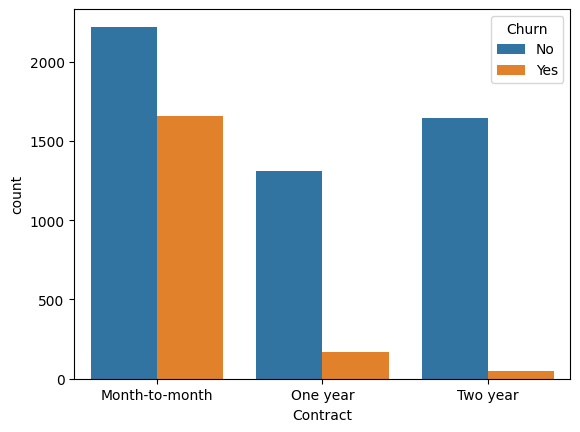

In [19]:
# feature vs target (does contract has high impact on churn)
sns.countplot(x='Contract',hue='Churn',data=df)

In [20]:
# Lets check percentage of churn based on contract, instead of raw data.
# What this does
# crosstab → counts combinations
# normalize='index' → converts to percentage per category
# *100 → makes it readable

churn_rate = pd.crosstab(df['Contract'],df['Churn'],normalize='index') * 100
print(churn_rate)

Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858


<Axes: xlabel='tenure', ylabel='Count'>

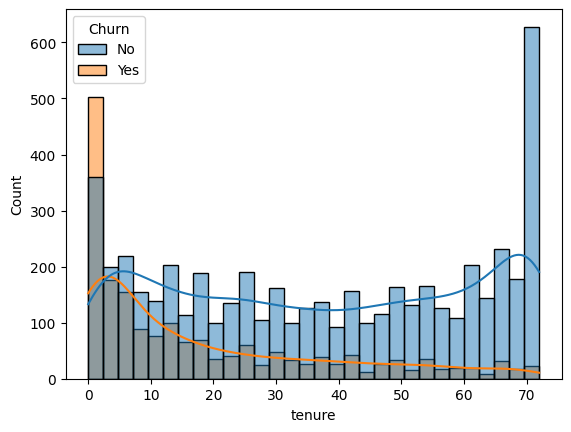

In [21]:
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, kde=True, alpha=0.5)

<Axes: xlabel='Churn', ylabel='tenure'>

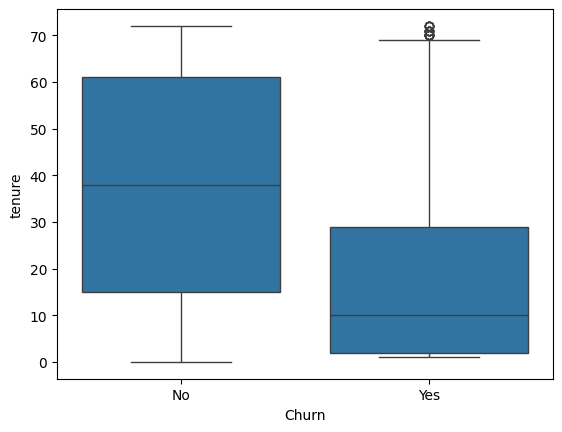

In [22]:
sns.boxplot(x='Churn', y='tenure', data=df)

In [23]:
# features and target
x = df.drop(columns='Churn')
y = df['Churn']

In [24]:
y = y.map({'Yes': 1, 'No': 0})

In [25]:
y.shape

(7043,)

In [26]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42)

In [27]:
#get num and string columns for scaling and encoding
num_cols = x.select_dtypes(include=['int64','float64']).columns
cat_cols = x.select_dtypes(include='object').columns

In [28]:
num_cols

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')

In [29]:
cat_cols

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

In [30]:
# preprocessor
preprocessor = ColumnTransformer([
    ('nums',StandardScaler(),num_cols),
    ('cats',OneHotEncoder(drop='first'),cat_cols)
])

In [31]:
#Logistic Pipeline
logistic_pipeline = Pipeline([
    ('preprocess',preprocessor),
    ('model',LogisticRegression())
])

In [33]:
logistic_pipeline.fit(x_train,y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('nums', StandardScaler(),
                                                  Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')),
                                                 ('cats',
                                                  OneHotEncoder(drop='first'),
                                                  Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object'))])),
                ('model', LogisticRegression())])

In [34]:
cross_score = cross_validate(logistic_pipeline,x_train,y_train,cv=5,scoring=['accuracy',"precision", "recall", "f1"])
cross_score

{'fit_time': array([0.05725169, 0.07226753, 0.06998706, 0.06630564, 0.07045889]),
 'score_time': array([0.02590156, 0.02419233, 0.02455831, 0.02565217, 0.04080677]),
 'test_accuracy': array([0.80628803, 0.81845842, 0.78803245, 0.79513185, 0.80831643]),
 'test_precision': array([0.65044248, 0.69607843, 0.61792453, 0.63507109, 0.68617021]),
 'test_recall': array([0.56756757, 0.54826255, 0.50579151, 0.51737452, 0.4980695 ]),
 'test_f1': array([0.60618557, 0.61339093, 0.55626327, 0.57021277, 0.57718121])}

In [36]:
# 1. Get feature names from the preprocessor
features = logistic_pipeline.named_steps['preprocess'].get_feature_names_out()

# 2. Get the coefficients
weights = logistic_pipeline.named_steps['model'].coef_[0]

# 3. Create a nice DataFrame
importance_df = pd.DataFrame({'Feature': features, 'Weight': weights})
importance_df = importance_df.sort_values(by='Weight', ascending=False)

print(importance_df)

                                        Feature    Weight
10            cats__InternetService_Fiber optic  0.950001
3                            nums__TotalCharges  0.633651
23                    cats__StreamingMovies_Yes  0.378386
28         cats__PaymentMethod_Electronic check  0.325015
26                   cats__PaperlessBilling_Yes  0.309369
9                       cats__MultipleLines_Yes  0.281182
21                        cats__StreamingTV_Yes  0.160166
0                           nums__SeniorCitizen  0.076272
17                   cats__DeviceProtection_Yes  0.033743
5                             cats__Partner_Yes  0.011439
29             cats__PaymentMethod_Mailed check -0.047403
4                             cats__gender_Male -0.072661
27  cats__PaymentMethod_Credit card (automatic) -0.073288
8          cats__MultipleLines_No phone service -0.081754
6                          cats__Dependents_Yes -0.116393
22    cats__StreamingMovies_No internet service -0.149653
14       cats_

In [37]:
param_grid = [
    {
        # Path A: The "Executioner" (Killing useless features)
        'model__penalty': ['l1'],
        'model__C': [0.01, 0.1, 1, 10],
        'model__solver': ['liblinear'],  # liblinear is the pro choice for L1 + small binary data
        'model__class_weight': ['balanced', None] # Test our "magic button"
    },
    {
        # Path B: The "Gentle Shrinker" (Standard optimization)
        'model__penalty': ['l2'],
        'model__C': [0.01, 0.1, 1, 10],
        'model__solver': ['lbfgs'],       # Standard robust solver
        'model__class_weight': ['balanced', None]
    }
]

In [38]:
grid = GridSearchCV(logistic_pipeline,param_grid=param_grid,cv=5,scoring='f1',verbose=2)
grid.fit(x_train,y_train)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
[CV] END model__C=0.01, model__class_weight=balanced, model__penalty=l1, model__solver=liblinear; total time=   0.0s
[CV] END model__C=0.01, model__class_weight=balanced, model__penalty=l1, model__solver=liblinear; total time=   0.0s
[CV] END model__C=0.01, model__class_weight=balanced, model__penalty=l1, model__solver=liblinear; total time=   0.0s
[CV] END model__C=0.01, model__class_weight=balanced, model__penalty=l1, model__solver=liblinear; total time=   0.0s
[CV] END model__C=0.01, model__class_weight=balanced, model__penalty=l1, model__solver=liblinear; total time=   0.1s
[CV] END model__C=0.01, model__class_weight=None, model__penalty=l1, model__solver=liblinear; total time=   0.1s
[CV] END model__C=0.01, model__class_weight=None, model__penalty=l1, model__solver=liblinear; total time=   0.1s
[CV] END model__C=0.01, model__class_weight=None, model__penalty=l1, model__solver=liblinear; total time=   0.1s
[CV] END model_

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocess',
                                        ColumnTransformer(transformers=[('nums',
                                                                         StandardScaler(),
                                                                         Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')),
                                                                        ('cats',
                                                                         OneHotEncoder(drop='first'),
                                                                         Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBacku...
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object'))])),
                                       ('model', LogisticRegression())]),
             param_grid=[{'model__C': [0.01, 0.1, 1, 10],
                          'model__class_weight': ['balanced', None],
                          'model__penalty': ['l1'],
                          'model__solver': ['liblinear']},
                         {'model__C': [0.01, 0.1, 1, 10],
                          'model__class_weight': ['balanced', None],
                          'model__penalty': ['l2'],
                          'model__solver': ['lbfgs']}],
             scoring='f1', verbose=2)

In [40]:
print("Best Parameters:", grid.best_params_)
print("Best F1 Score:", grid.best_score_)

Best Parameters: {'model__C': 0.1, 'model__class_weight': 'balanced', 'model__penalty': 'l1', 'model__solver': 'liblinear'}
Best F1 Score: 0.6133148694265009


In [43]:
# Use the best model to predict
y_pred = grid.best_estimator_.predict(x_test)

# Import the professional report
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.73      0.81      1539
           1       0.53      0.83      0.65       574

    accuracy                           0.76      2113
   macro avg       0.73      0.78      0.73      2113
weighted avg       0.81      0.76      0.77      2113



In [44]:
# Get the winning model from the grid search
best_model = grid.best_estimator_

# Get the feature names and weights
features = best_model.named_steps['preprocess'].get_feature_names_out()
weights = best_model.named_steps['model'].coef_[0]

# Create the "After" dataframe
after_df = pd.DataFrame({'Feature': features, 'Weight': weights})
after_df = after_df.sort_values(by='Weight', ascending=False)

print(after_df)

                                        Feature    Weight
10            cats__InternetService_Fiber optic  0.548429
28         cats__PaymentMethod_Electronic check  0.360789
26                   cats__PaperlessBilling_Yes  0.269659
2                          nums__MonthlyCharges  0.254412
23                    cats__StreamingMovies_Yes  0.227953
3                            nums__TotalCharges  0.224666
9                       cats__MultipleLines_Yes  0.098611
0                           nums__SeniorCitizen  0.079402
8          cats__MultipleLines_No phone service  0.000000
27  cats__PaymentMethod_Credit card (automatic)  0.000000
17                   cats__DeviceProtection_Yes  0.000000
29             cats__PaymentMethod_Mailed check  0.000000
21                        cats__StreamingTV_Yes  0.000000
5                             cats__Partner_Yes  0.000000
16   cats__DeviceProtection_No internet service -0.000182
18        cats__TechSupport_No internet service -0.000189
12     cats__O

Random-Forest

In [46]:
random_forest_Pipeline = Pipeline([
    ('preprocessor',preprocessor),
    ('model',RandomForestClassifier())
])

In [47]:
random_forest_Pipeline.fit(x_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('nums', StandardScaler(),
                                                  Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')),
                                                 ('cats',
                                                  OneHotEncoder(drop='first'),
                                                  Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object'))])),
                ('model', RandomForestClassifier())])

In [49]:
random_forest_cross_score = cross_validate(random_forest_Pipeline,x_train,y_train,cv=5,scoring=['accuracy',"precision", "recall", "f1"])
random_forest_cross_score

{'fit_time': array([0.53130841, 0.53903127, 0.56198168, 0.77790713, 0.79316783]),
 'score_time': array([0.03983188, 0.03672481, 0.05220509, 0.0554204 , 0.05127096]),
 'test_accuracy': array([0.79107505, 0.80831643, 0.78803245, 0.79107505, 0.78701826]),
 'test_precision': array([0.62926829, 0.69230769, 0.62376238, 0.63874346, 0.64      ]),
 'test_recall': array([0.4980695 , 0.48648649, 0.48648649, 0.47104247, 0.43243243]),
 'test_f1': array([0.55603448, 0.57142857, 0.54663774, 0.54222222, 0.51612903])}

In [50]:
random_grid_params = {
    "model__n_estimators":[100,200],
    "model__max_depth":[10,20,None],
    "model__min_samples_split":[2,5,20],
    "model__min_samples_leaf":[1,2,4],
    "model__max_features": ['sqrt', 'log2'],
    'model__class_weight': ['balanced']
}

In [ ]:
random_forest_gridsearch = GridSearchCV(random_forest_Pipeline,param_grid=random_grid_params,scoring='f1',verbose=2,cv=5)
random_forest_gridsearch.fit(x_train,y_train)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
[CV] END model__class_weight=balanced, model__max_depth=10, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=100; total time=   0.5s
[CV] END model__class_weight=balanced, model__max_depth=10, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=100; total time=   0.5s
[CV] END model__class_weight=balanced, model__max_depth=10, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=100; total time=   0.4s
[CV] END model__class_weight=balanced, model__max_depth=10, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=100; total time=   0.5s
[CV] END model__class_weight=balanced, model__max_depth=10, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=100; total time=   0.6s
[CV] END mod

In [53]:
print('best params: ',random_forest_gridsearch.best_params_)
print('best score: ',random_forest_gridsearch.best_score_)

best params:  {'model__class_weight': 'balanced', 'model__max_depth': 20, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 4, 'model__min_samples_split': 20, 'model__n_estimators': 100}
best score:  0.6291179614988224


In [54]:
# Use the best model to predict
y_pred_forest = random_forest_gridsearch.best_estimator_.predict(x_test)

# Import the professional report
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred_forest))

              precision    recall  f1-score   support

           0       0.90      0.79      0.84      1539
           1       0.57      0.76      0.65       574

    accuracy                           0.78      2113
   macro avg       0.73      0.77      0.75      2113
weighted avg       0.81      0.78      0.79      2113



XGBoost

In [55]:
from xgboost import XGBClassifier

In [56]:
xg_pipeline = Pipeline([
    ('preprocess',preprocessor),
    ('model',XGBClassifier(
        use_label_encoder= False,
        eval_metric='logloss',
        random_state=42,
    ))
])

In [58]:
xg_pipeline.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:23:12] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('nums', StandardScaler(),
                                                  Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')),
                                                 ('cats',
                                                  OneHotEncoder(drop='first'),
                                                  Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechS...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [59]:
xgb_param_grid = {
    'model__n_estimators': [100, 200],
    'model__learning_rate': [0.01, 0.1],
    'model__max_depth': [3, 5],
    'model__min_child_weight': [1, 5],    # The "Leaf" replacement
    'model__gamma': [0, 0.1, 0.2],         # The "Threshold" for a split
    'model__subsample': [0.8, 1.0],
    'model__colsample_bytree': [0.8, 1.0],
    'model__scale_pos_weight': [3]         # We keep it at 3 to focus on Recall
}

In [60]:
xgb_gridsearch = GridSearchCV(xg_pipeline,param_grid=xgb_param_grid,scoring='f1',verbose=2,cv=5)
xgb_gridsearch.fit(x_train,y_train)

Fitting 5 folds for each of 192 candidates, totalling 960 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:29:43] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END model__colsample_bytree=0.8, model__gamma=0, model__learning_rate=0.01, model__max_depth=3, model__min_child_weight=1, model__n_estimators=100, model__scale_pos_weight=3, model__subsample=0.8; total time=   0.3s


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:29:44] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END model__colsample_bytree=0.8, model__gamma=0, model__learning_rate=0.01, model__max_depth=3, model__min_child_weight=1, model__n_estimators=100, model__scale_pos_weight=3, model__subsample=0.8; total time=   0.6s


...

[CV] END model__colsample_bytree=1.0, model__gamma=0.2, model__learning_rate=0.1, model__max_depth=5, model__min_child_weight=5, model__n_estimators=200, model__scale_pos_weight=3, model__subsample=1.0; total time=   0.2s
[CV] END model__colsample_bytree=1.0, model__gamma=0.2, model__learning_rate=0.1, model__max_depth=5, model__min_child_weight=5, model__n_estimators=200, model__scale_pos_weight=3, model__subsample=1.0; total time=   0.2s


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:33:00] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:33:00] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END model__colsample_bytree=1.0, model__gamma=0.2, model__learning_rate=0.1, model__max_depth=5, model__min_child_weight=5, model__n_estimators=200, model__scale_pos_weight=3, model__subsample=1.0; total time=   0.2s


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:33:00] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocess',
                                        ColumnTransformer(transformers=[('nums',
                                                                         StandardScaler(),
                                                                         Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')),
                                                                        ('cats',
                                                                         OneHotEncoder(drop='first'),
                                                                         Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBacku...
                                                      multi_strategy=None,
                                                      n_estimators=None,
                                                      n_jobs=None,
                                                      num_parallel_tree=None, ...))]),
             param_grid={'model__colsample_bytree': [0.8, 1.0],
                         'model__gamma': [0, 0.1, 0.2],
                         'model__learning_rate': [0.01, 0.1],
                         'model__max_depth': [3, 5],
                         'model__min_child_weight': [1, 5],
                         'model__n_estimators': [100, 200],
                         'model__scale_pos_weight': [3],
                         'model__subsample': [0.8, 1.0]},
             scoring='f1', verbose=2)

In [61]:
print('params: ',xgb_gridsearch.best_params_)
print('best score: ',xgb_gridsearch.best_score_)

params:  {'model__colsample_bytree': 0.8, 'model__gamma': 0.2, 'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__min_child_weight': 5, 'model__n_estimators': 100, 'model__scale_pos_weight': 3, 'model__subsample': 0.8}
best score:  0.6258017749541096


In [62]:
xgb_y_pred = xgb_gridsearch.best_estimator_.predict(x_test)

print(classification_report(y_test,xgb_y_pred))

              precision    recall  f1-score   support

           0       0.91      0.74      0.82      1539
           1       0.53      0.79      0.64       574

    accuracy                           0.76      2113
   macro avg       0.72      0.77      0.73      2113
weighted avg       0.80      0.76      0.77      2113

